# Import

In [161]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tikzplotlib

# Results directory

In [162]:
RESULTS_DIR_HOMO = Path("results/time_per_it_10")
RESULTS_DIR_HETERO = Path("results/time_per_it_11")

# File

In [163]:
DATA_HOMO = RESULTS_DIR_HOMO / "compromise_results.csv"
COLLECTIVE_HOMO = RESULTS_DIR_HOMO / "collective_results.csv"
PATH_HOMO = RESULTS_DIR_HOMO / "path_results.csv"

DATA_HETERO = RESULTS_DIR_HETERO / "compromise_results.csv"
COLLECTIVE_HETERO = RESULTS_DIR_HETERO / "collective_results.csv"
PATH_HETERO = RESULTS_DIR_HETERO / "path_results.csv"

# Read files

In [164]:
df_homo = pd.read_csv(DATA_HOMO)
df_homo["Group"] = "Homo"
df_collective_homo = pd.read_csv(COLLECTIVE_HOMO)
df_collective_homo["Group"] = "Homo"
df_path_homo = pd.read_csv(PATH_HOMO)
df_path_homo["Group"] = "Homo"

df_hetero = pd.read_csv(DATA_HETERO)
df_hetero["Group"] = "Hetero"
df_collective_hetero = pd.read_csv(COLLECTIVE_HETERO)
df_collective_hetero["Group"] = "Hetero"
df_path_hetero = pd.read_csv(PATH_HETERO)
df_path_hetero["Group"] = "Hetero"

df = pd.concat([df_homo, df_hetero])
df_collective = pd.concat([df_collective_homo, df_collective_hetero])
df_path = pd.concat([df_path_homo, df_path_hetero])

In [165]:
df

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Mie_config,Mie_id,Mc_id,Nb_Mcp,Path,P_id,Compromise,Time,It,Changes
0,3,100,1,1,1,2,Homo,1,10,True,...,NaN,1,1,1,False,1,True,0.468387,1,2
1,3,100,2,1,2,2,Homo,2,10,True,...,NaN,2,2,1,False,2,True,0.296798,1,1
2,3,100,1,1,1,2,Homo,1,10,True,...,NaN,1,1,1,True,1,True,1.076321,1,2
3,3,100,4,1,4,2,Homo,4,10,True,...,NaN,4,4,1,False,4,True,0.310810,1,3
4,3,100,0,1,0,2,Homo,0,10,True,...,NaN,0,0,1,False,0,True,0.577076,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2695,5,100,2,2,2,6,Hetero,2,50,True,...,NaN,2,2,1,True,2,False,3600.094309,15,54
2696,4,100,7,3,7,6,Hetero,7,50,True,...,NaN,7,7,1,False,7,True,3434.147167,27,143
2697,5,100,2,2,2,6,Hetero,2,50,True,...,NaN,2,2,1,False,2,True,2950.512162,24,112
2698,5,100,4,3,4,4,Hetero,4,50,True,...,NaN,4,4,1,True,4,False,3600.074138,15,52


In [166]:
df_collective

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Mie_config,Mie_id,Mc_id,Nb_Mcp,Path,P_id,It,Time,Objective,Optimal
0,3,100,1,1,1,2,Homo,1,10,True,...,NaN,1,1,1,True,1,0,0.133291,1.0,True
1,3,100,1,1,1,2,Homo,1,10,True,...,NaN,1,1,1,False,1,0,0.139848,1.0,True
2,3,100,0,1,0,2,Homo,0,10,True,...,NaN,0,0,1,True,0,0,0.135890,2.0,True
3,3,100,0,1,0,2,Homo,0,10,True,...,NaN,0,0,1,False,0,0,0.208860,2.0,True
4,3,100,2,1,2,2,Homo,2,10,True,...,NaN,2,2,1,False,2,0,0.078601,1.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6984,5,100,4,3,4,4,Hetero,4,50,True,...,NaN,4,4,1,False,4,21,121.667720,17.0,False
6985,5,100,4,3,4,4,Hetero,4,50,True,...,NaN,4,4,1,False,4,22,121.643565,17.0,False
6986,5,100,4,3,4,4,Hetero,4,50,True,...,NaN,4,4,1,False,4,23,121.690167,17.0,False
6987,5,100,4,3,4,4,Hetero,4,50,True,...,NaN,4,4,1,False,4,24,121.470484,17.0,False


In [167]:
df_path

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Mc_id,Nb_Mcp,Path,P_id,It,Dm_id,Time,Length,Model_Length,Found
0,3,100,1,1,1,2,Homo,1,10,True,...,1,1,True,1,0,0,0.000003,1,2,True
1,3,100,1,1,1,2,Homo,1,10,True,...,1,1,True,1,0,1,0.000003,1,2,True
2,3,100,0,1,0,2,Homo,0,10,True,...,0,1,True,0,0,1,0.789803,2,7,True
3,3,100,0,1,0,2,Homo,0,10,True,...,0,1,True,0,0,0,0.970569,2,9,True
4,3,100,2,1,2,2,Homo,2,10,True,...,2,1,True,2,0,1,0.000003,1,2,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13531,5,100,4,3,4,4,Hetero,4,50,True,...,4,1,True,4,13,3,120.027632,1,1,False
13532,5,100,4,3,4,4,Hetero,4,50,True,...,4,1,True,4,14,1,18.264384,1,1,False
13533,5,100,4,3,4,4,Hetero,4,50,True,...,4,1,True,4,14,2,18.259150,1,1,False
13534,5,100,4,3,4,4,Hetero,4,50,True,...,4,1,True,4,14,3,18.284833,1,1,False


<!-- # Correction -->

In [168]:
df_collective["Objective"] = df_collective["Objective"] % df_collective["N_bc"]

# Group by

In [169]:
df_collective_exp = df_collective.groupby(by=["M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Method",
        "Config",
        "Mc_id",
        "Nb_Mcp",
        "Path",
        "P_id"], as_index=False).mean()
df_collective_exp

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Nb_Mcp,Path,P_id,Mie,Mie_config,Mie_id,It,Time,Objective,Optimal
0,3,100,0,1,0,2,Hetero,0,10,True,...,1,False,0,0.0,NaN,0.0,0.0,0.082614,2.0,1.0
1,3,100,0,1,0,2,Hetero,0,10,True,...,1,True,0,0.0,NaN,0.0,0.0,0.103283,2.0,1.0
2,3,100,0,1,0,2,Hetero,0,20,True,...,1,False,0,0.0,NaN,0.0,0.0,0.258288,5.0,1.0
3,3,100,0,1,0,2,Hetero,0,20,True,...,1,True,0,0.0,NaN,0.0,0.5,0.359788,5.5,1.0
4,3,100,0,1,0,2,Hetero,0,30,True,...,1,False,0,0.0,NaN,0.0,0.0,1.663036,11.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5161,5,100,9,3,9,6,Hetero,9,30,True,...,1,True,9,0.0,NaN,9.0,0.0,121.163414,9.0,0.0
5162,5,100,9,3,9,6,Hetero,9,40,True,...,1,False,9,0.0,NaN,9.0,0.0,121.341470,13.0,0.0
5163,5,100,9,3,9,6,Hetero,9,40,True,...,1,True,9,0.0,NaN,9.0,0.0,121.409924,13.0,0.0
5164,5,100,9,3,9,6,Hetero,9,50,True,...,1,False,9,0.0,NaN,9.0,0.0,121.788237,14.0,0.0


# New attributes

In [170]:
# df["Gen"] = np.array(["Homogene", "Heterogene"])[df["Group"] % 2]
# df["Accept"] = np.array(["Conservative", "Tolerant"])[df["Group"] % 2]

df["Changes_Mean"] = df["Changes"] / df["Group_size"]
df["Changes_Prop"] = df["Changes"] / (df["N_bc"] * df["Group_size"])

df_collective_exp["Objective_Prop"] = df_collective_exp["Objective"] / df_collective_exp["N_bc"]

df["Time_Per_It"] = df["Time"] / df["It"]

df["It_Nbc"] = df["It"] / df["N_bc"]

In [171]:
# from math import inf


# df_collective.loc[df_collective["Objective"] == inf, "Time"] = 600

# Filter

In [172]:
# dff = df[df["Fitness_train"] == 1]
# dff = df[df["N_tr"].isin([10, 20, 30, 80, 90, 100])]
# dff = df[df["N_tr"] % 20 == 0]
dff = df
dff = dff[~df["Mie"]]
dff = dff.drop(columns=["Mie", "Mie_id"])
# dff = dff[dff["Group_size"] == 2]
# dff = dff[dff["M"] <= 4]
# dff = dff[dff["Ko"] <= 3]
# dff = dff[dff["Gen"] == "Homogene"]
# dff = dff[dff["Path"]]
# dff = dff[dff["Compromise"]]
dff = dff[dff["It"] < 2 * dff["N_bc"]]
df_collective = df_collective[df_collective["It"] < 2 * df_collective["N_bc"]]

In [173]:
dff

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Path,P_id,Compromise,Time,It,Changes,Changes_Mean,Changes_Prop,Time_Per_It,It_Nbc
0,3,100,1,1,1,2,Homo,1,10,True,...,False,1,True,0.468387,1,2,1.000000,0.100000,0.468387,0.10
1,3,100,2,1,2,2,Homo,2,10,True,...,False,2,True,0.296798,1,1,0.500000,0.050000,0.296798,0.10
2,3,100,1,1,1,2,Homo,1,10,True,...,True,1,True,1.076321,1,2,1.000000,0.100000,1.076321,0.10
3,3,100,4,1,4,2,Homo,4,10,True,...,False,4,True,0.310810,1,3,1.500000,0.150000,0.310810,0.10
4,3,100,0,1,0,2,Homo,0,10,True,...,False,0,True,0.577076,1,4,2.000000,0.200000,0.577076,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2695,5,100,2,2,2,6,Hetero,2,50,True,...,True,2,False,3600.094309,15,54,9.000000,0.180000,240.006287,0.30
2696,4,100,7,3,7,6,Hetero,7,50,True,...,False,7,True,3434.147167,27,143,23.833333,0.476667,127.190636,0.54
2697,5,100,2,2,2,6,Hetero,2,50,True,...,False,2,True,2950.512162,24,112,18.666667,0.373333,122.938007,0.48
2698,5,100,4,3,4,4,Hetero,4,50,True,...,True,4,False,3600.074138,15,52,13.000000,0.260000,240.004943,0.30


# Merge data

In [174]:
# df = pd.merge(
#     df_mip,
#     df_path,
#     how="left",
#     on=[
#         "M",
#         "N_tr",
#         "Atr_id",
#         "Ko",
#         "Mo_id",
#         "Group_size",
#         "Group",
#         "Mi_id",
#         "N_bc",
#         "Same_alt",
#         "D_id",
#         "Config",
#         "Mc_id",
#         "Path",
#         "P_id",
#         "It"
#     ],
#     suffixes=["_mip", "_path"],
# )


df_compromise_path = dff[dff["Path"]]
df_compromise_path = df_compromise_path[df_compromise_path["Compromise"]]
df_compromise_path_index = df_compromise_path.drop(
    columns=["Path", "Compromise", "Time", "It", "Changes", "Changes_Prop"]
)
df_compromise_no_path = dff[~dff["Path"]]
df_compromise_no_path = df_compromise_no_path[df_compromise_no_path["Compromise"]]
df_compromise_no_path_index = df_compromise_no_path.drop(
    columns=["Path", "Compromise", "Time", "It", "Changes", "Changes_Prop"]
)

df_compromise_index = pd.merge(
    df_compromise_path_index,
    df_compromise_no_path_index,
    how="inner",
    on=[
        "M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Config",
        "P_id",
        "Mc_id",
        "P_id",
        "Gen",
        "Accept",
    ],
)

df_compromise_path = pd.merge(
    df_compromise_path,
    df_compromise_index,
    how="inner",
    on=[
        "M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Config",
        "P_id",
        "Mc_id",
        "P_id",
        "Gen",
        "Accept",
    ],
    suffixes=["", ""],
)

df_compromise_no_path = pd.merge(
    df_compromise_no_path,
    df_compromise_index,
    how="inner",
    on=[
        "M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Config",
        "P_id",
        "Mc_id",
        "P_id",
        "Gen",
        "Accept",
    ],
    suffixes=["", ""],
)

# df_compromise = pd.merge(
#     df_compromise_path,
#     df_compromise_no_path,
#     how="inner",
#     on=[
#         "M",
#         "N_tr",
#         "Atr_id",
#         "Ko",
#         "Mo_id",
#         "Group_size",
#         "Group",
#         "Mi_id",
#         "N_bc",
#         "Same_alt",
#         "D_id",
#         "Config",
#         "Mie",
#         "P_id",
#         "Mie_id",
#         "Mc_id",
#         "P_id",
#         "Gen",
#         "Accept"
#     ],
#     suffixes=["_path", "_no_path"],
# )

df_compromise = pd.concat([df_compromise_path, df_compromise_no_path])

df_compromise

KeyError: 'Gen'

# Plot

## Compromise

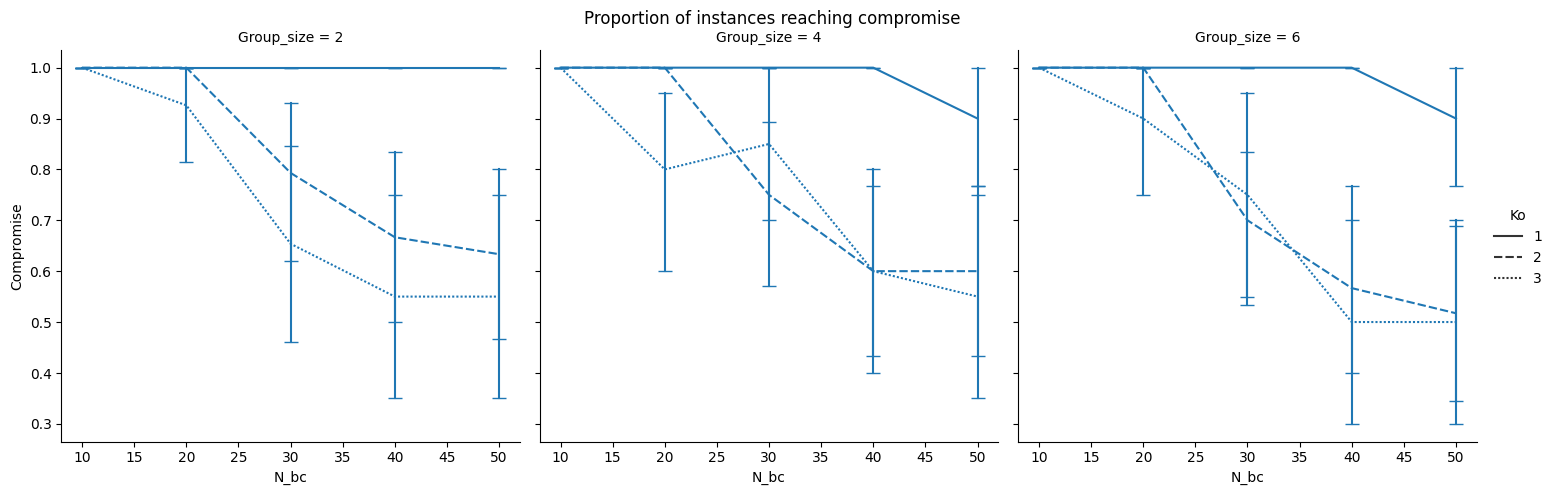

In [188]:
g = sns.relplot(
    dff[(dff["Group"] == "Homo") & (~dff["Path"])],
    x="N_bc",
    y="Compromise",
    # row="Group",
    col="Group_size",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Proportion of instances reaching compromise")
g

tikzplotlib.save("mytikz.tex", standalone=True)

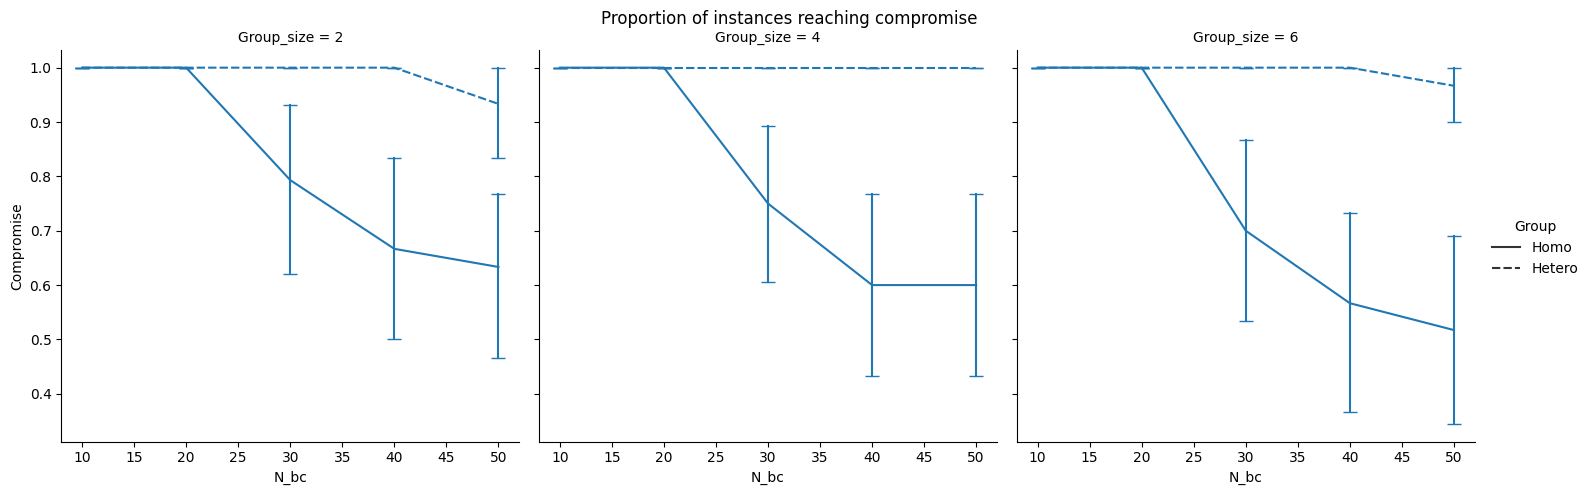

In [181]:
g = sns.relplot(
    dff[~dff["Path"] & (dff["Ko"] == 2)],
    x="N_bc",
    y="Compromise",
    # row="Group",
    col="Group_size",
    style="Group",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Proportion of instances reaching compromise")
g

tikzplotlib.save("mytikz.tex", standalone=True)

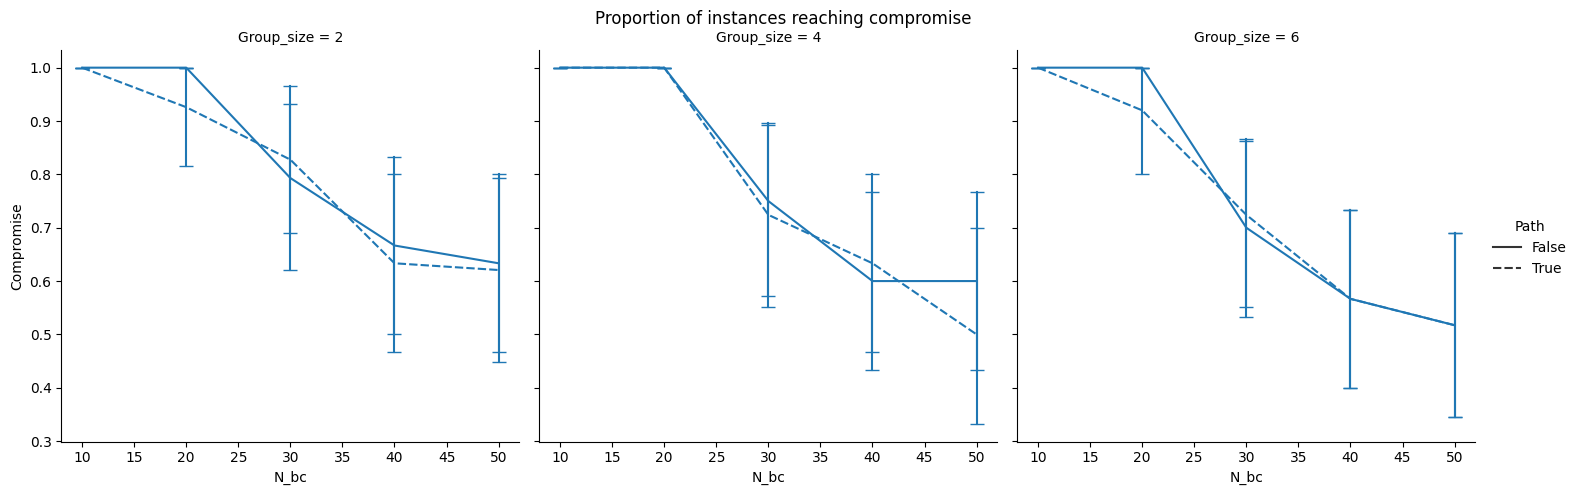

In [ ]:
g = sns.relplot(
    dff[(dff["Group"] == "Homo") & (dff["Ko"] == 2)],
    x="N_bc",
    y="Compromise",
    # row="Group",
    col="Group_size",
    style="Path",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Proportion of instances reaching compromise")
g

tikzplotlib.save("mytikz.tex", standalone=True)

## Sum of changes

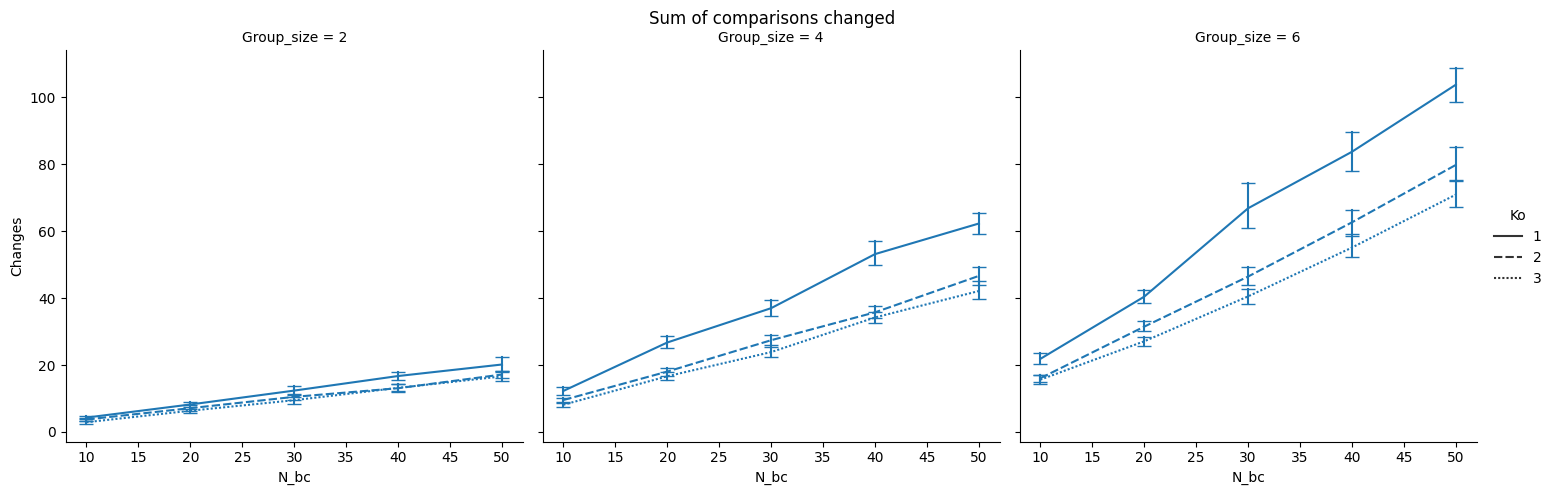

In [ ]:
g = sns.relplot(
    dff[dff["Compromise"]],
    x="N_bc",
    y="Changes",
    # row="Group_size",
    col="Group_size",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Sum of comparisons changed")
g

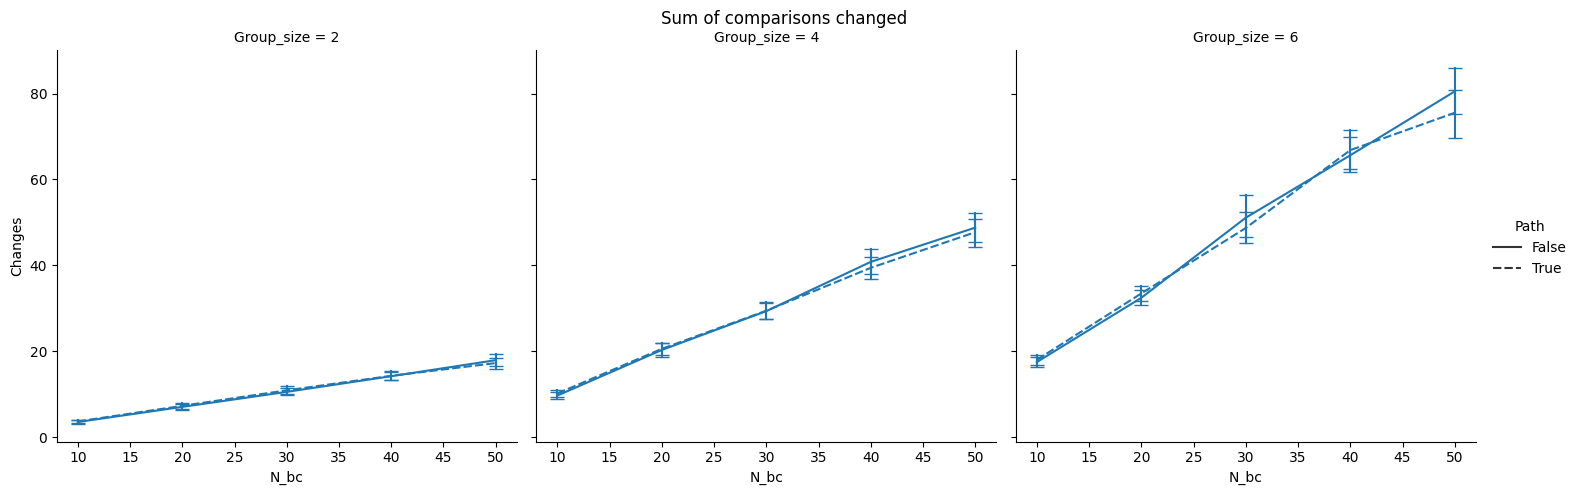

In [ ]:
g = sns.relplot(
    dff,
    x="N_bc",
    y="Changes",
    # row="Group_size",
    col="Group_size",
    style="Path",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Sum of comparisons changed")
g

## Mean of changes

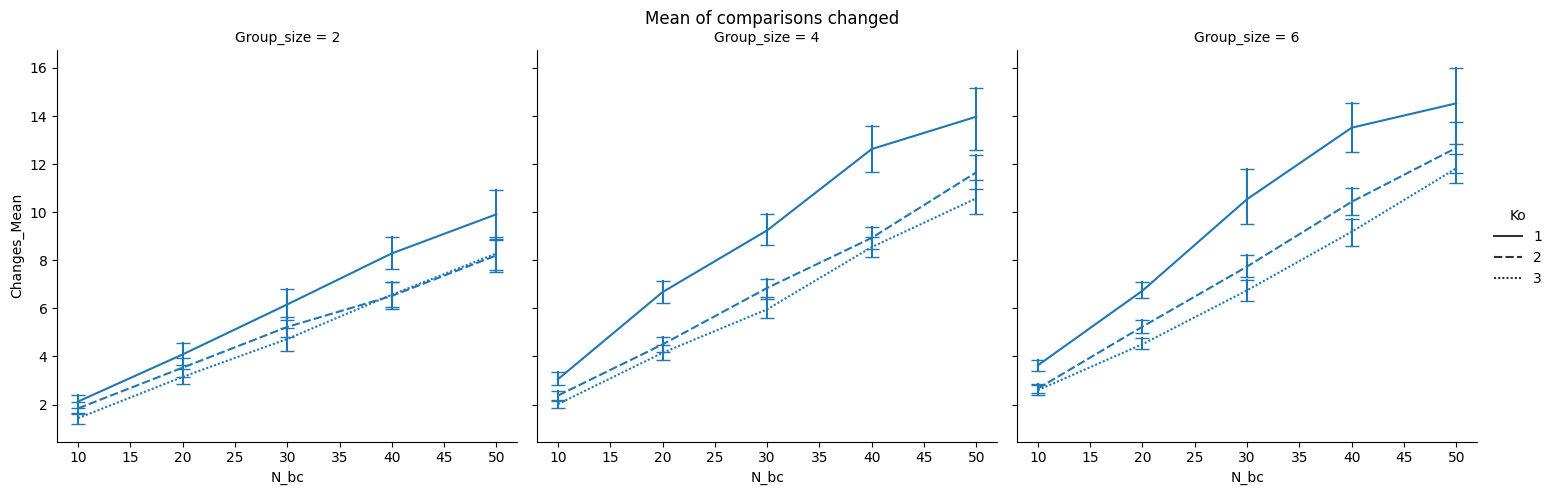

In [ ]:
g = sns.relplot(
    dff,
    x="N_bc",
    y="Changes_Mean",
    # row="Group_size",
    col="Group_size",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Mean of comparisons changed")
g

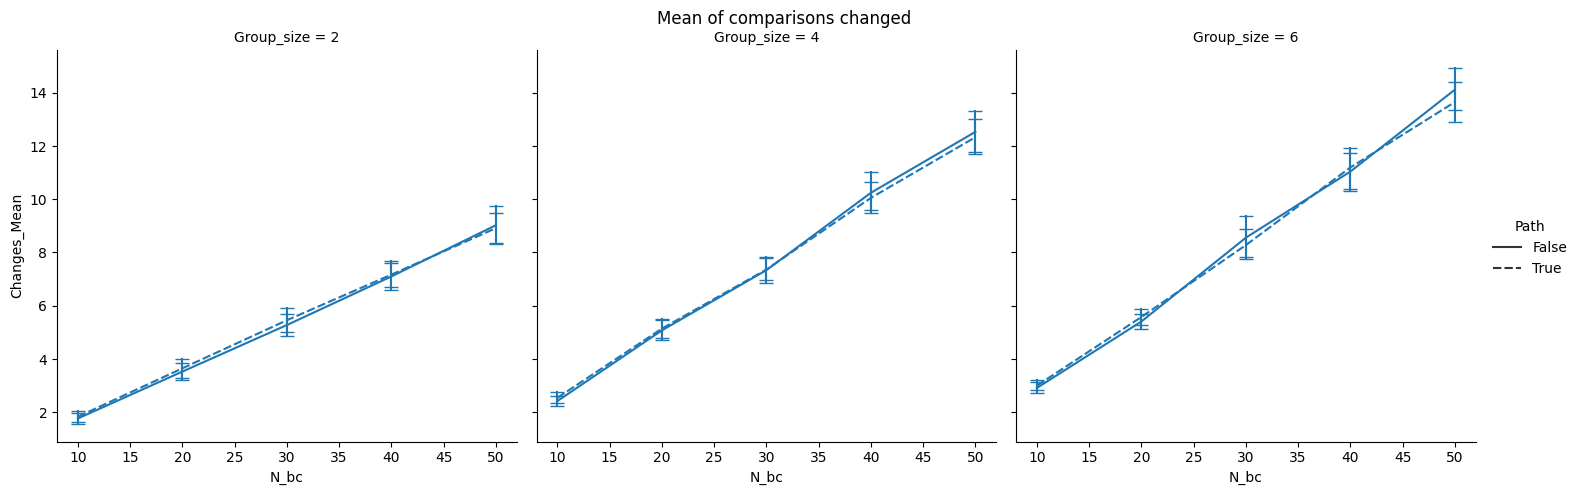

In [ ]:
g = sns.relplot(
    dff[dff["Compromise"]],
    x="N_bc",
    y="Changes_Mean",
    # row="Group_size",
    col="Group_size",
    style="Path",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Mean of comparisons changed")
g

## Proportion of changes

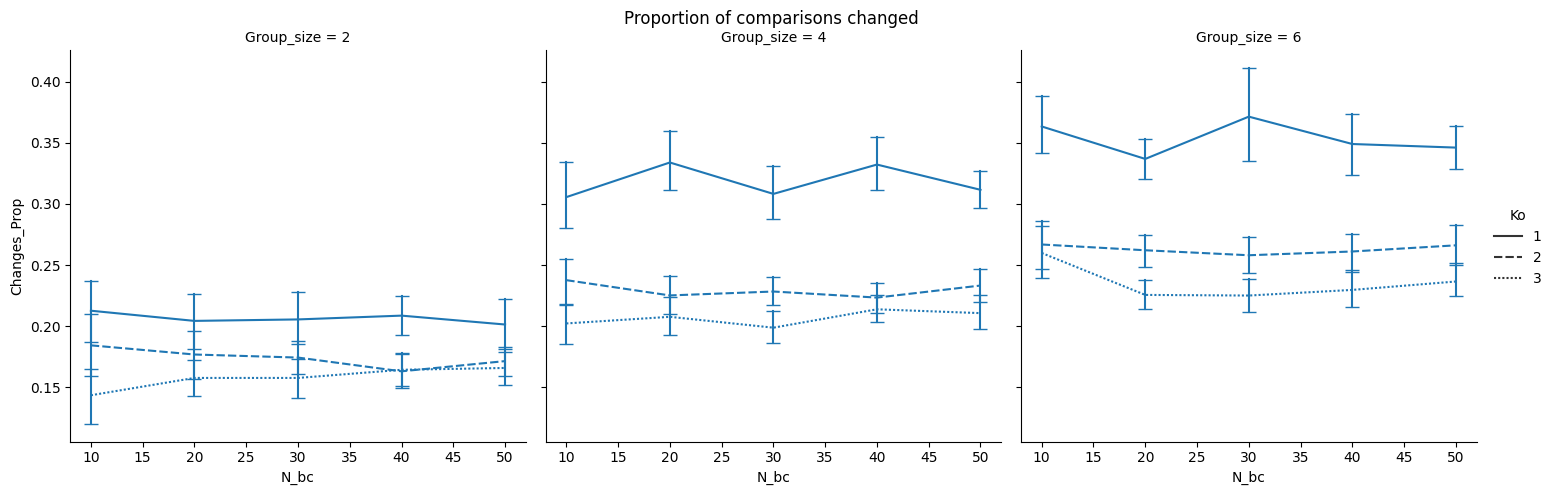

In [ ]:
g = sns.relplot(
    dff[dff["Compromise"]],
    x="N_bc",
    y="Changes_Prop",
    # row="Group_size",
    col="Group_size",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Proportion of comparisons changed")
g

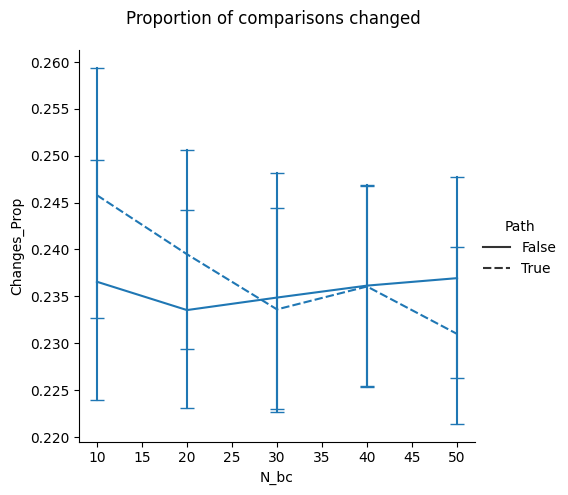

In [ ]:
g = sns.relplot(
    dff[dff["Compromise"]],
    x="N_bc",
    y="Changes_Prop",
    # row="Group_size",
    # col="M",
    style="Path",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Proportion of comparisons changed")
g

## MILP objective value

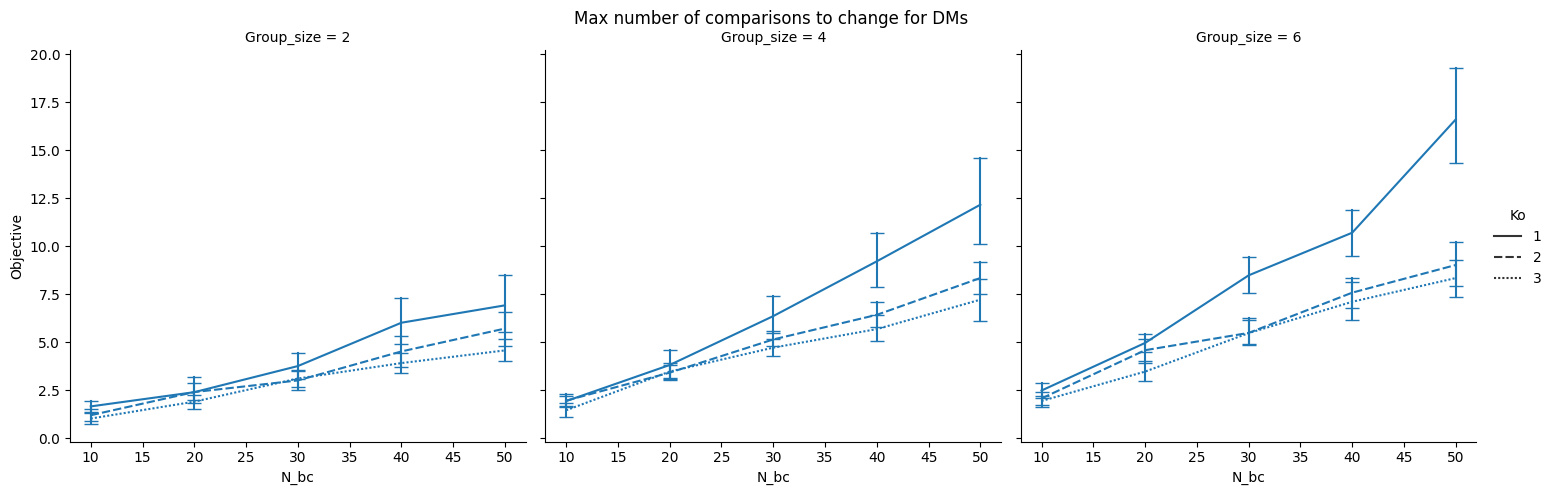

In [179]:
g = sns.relplot(
    df_collective_exp[(~df_collective_exp["Path"]) & (df_collective_exp["Group"] == "Homo")],
    x="N_bc",
    y="Objective",
    # row="Group",
    col="Group_size",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Max number of comparisons to change for DMs")
g

tikzplotlib.save("mytikz.tex", standalone=True)

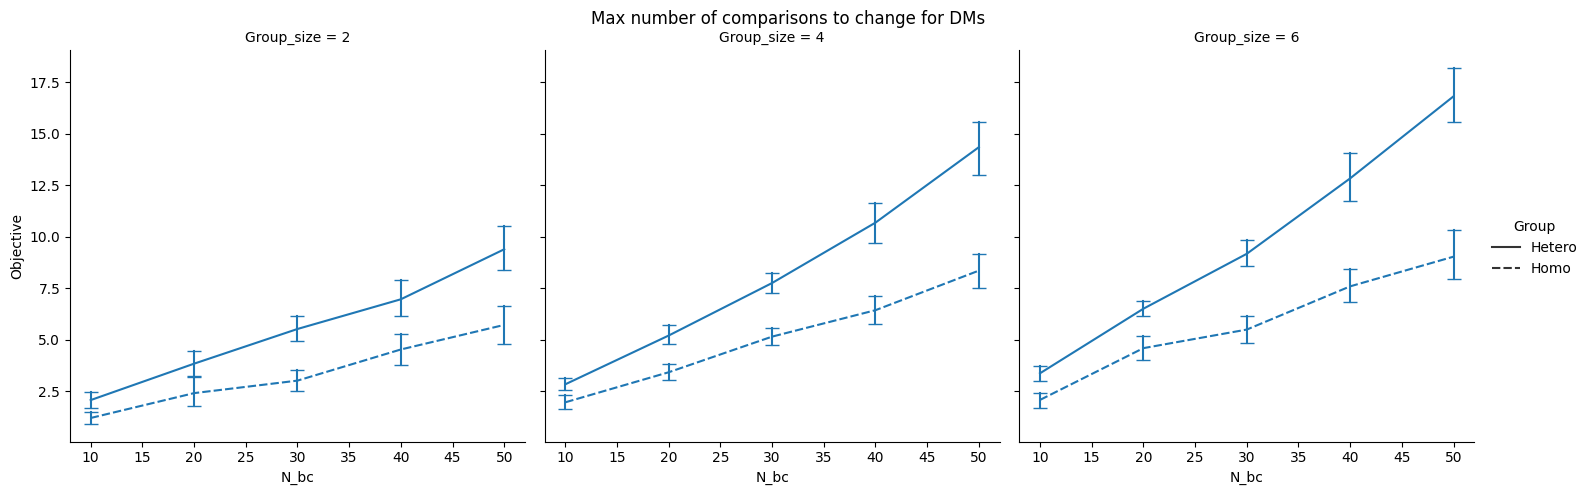

In [187]:
g = sns.relplot(
    df_collective_exp[(~df_collective_exp["Path"]) & (df_collective_exp["Ko"] == 2)],
    x="N_bc",
    y="Objective",
    # row="Group",
    col="Group_size",
    style="Group",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Max number of comparisons to change for DMs")
g

tikzplotlib.save("mytikz.tex", standalone=True)

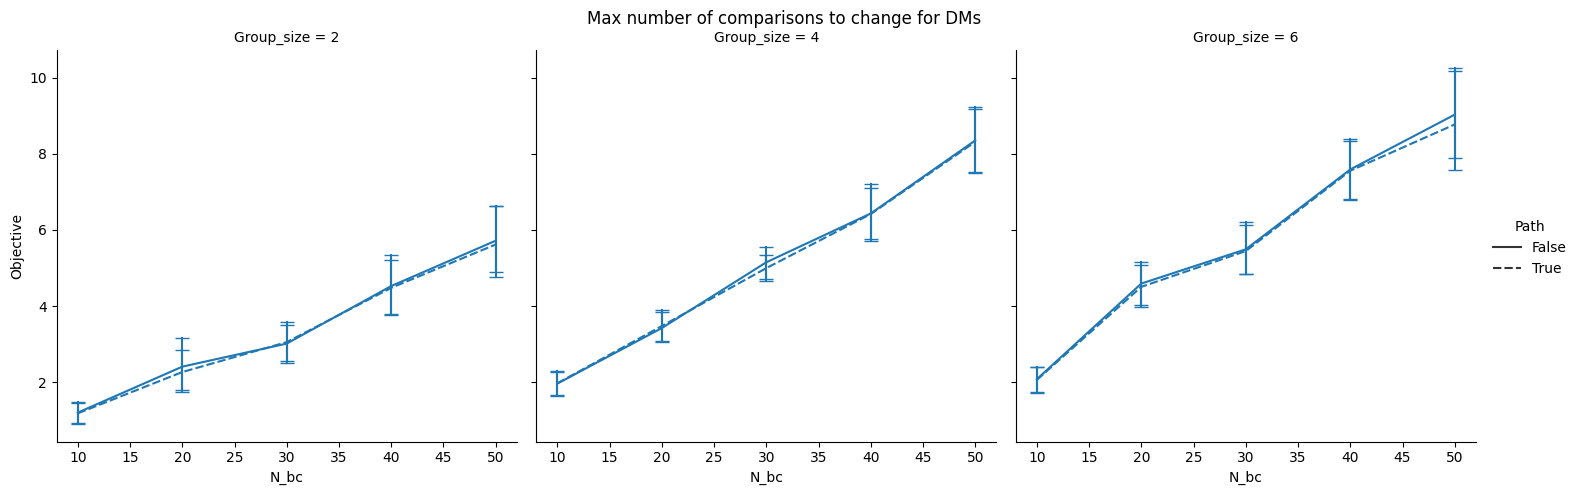

In [ ]:
g = sns.relplot(
    df_collective_exp[(df_collective_exp["Group"] == "Homo") & (df_collective_exp["Ko"] == 2)],
    x="N_bc",
    y="Objective",
    col="Group_size",
    # col="M",
    style="Path",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Max number of comparisons to change for DMs")
g

tikzplotlib.save("mytikz.tex", standalone=True)

## Proportion MILP objective value

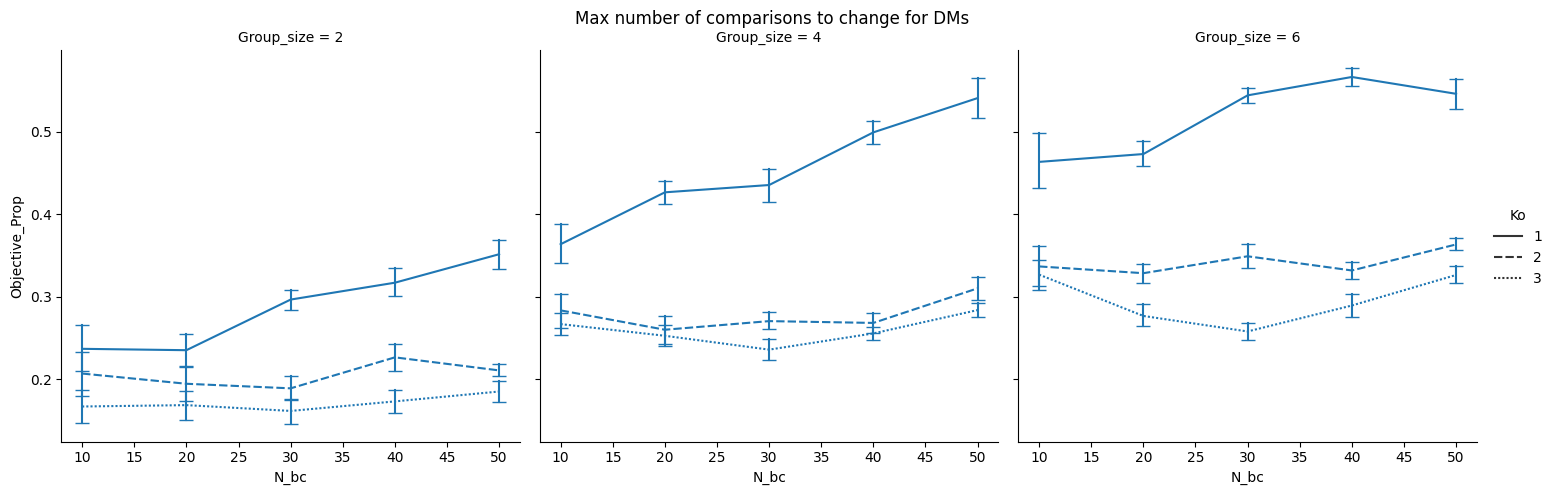

In [ ]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Objective_Prop",
    # row="Group_size",
    col="Group_size",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Max number of comparisons to change for DMs")
g

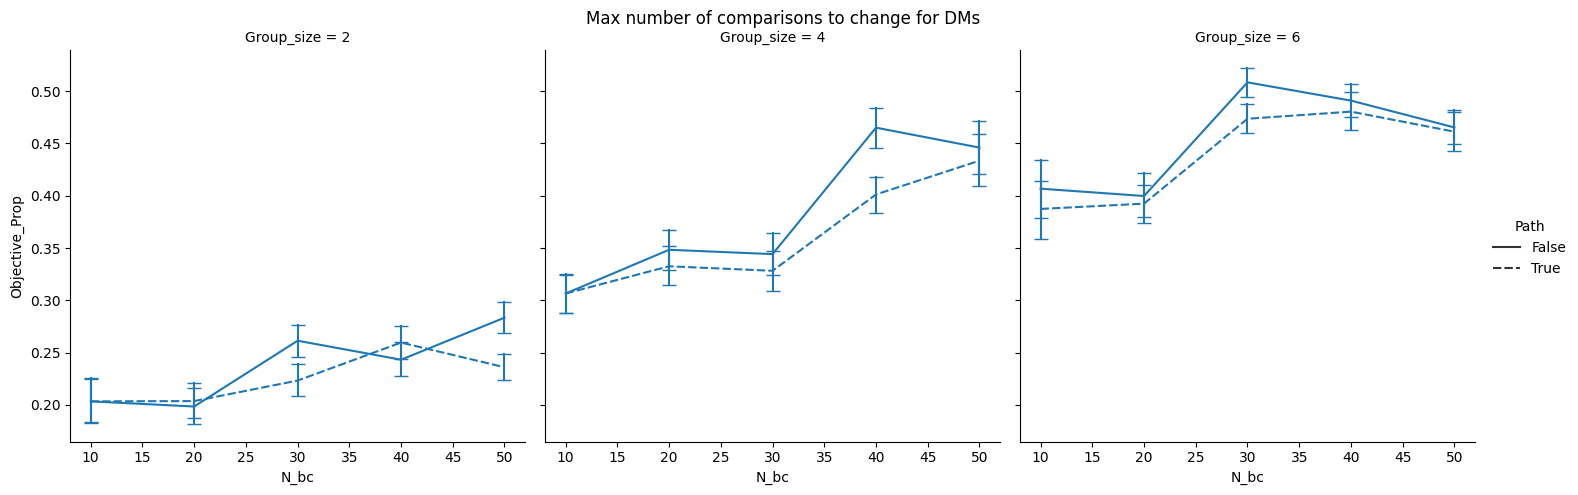

In [ ]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Objective_Prop",
    # row="Group_size",
    col="Group_size",
    style="Path",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Max number of comparisons to change for DMs")
g

## MILP optimal

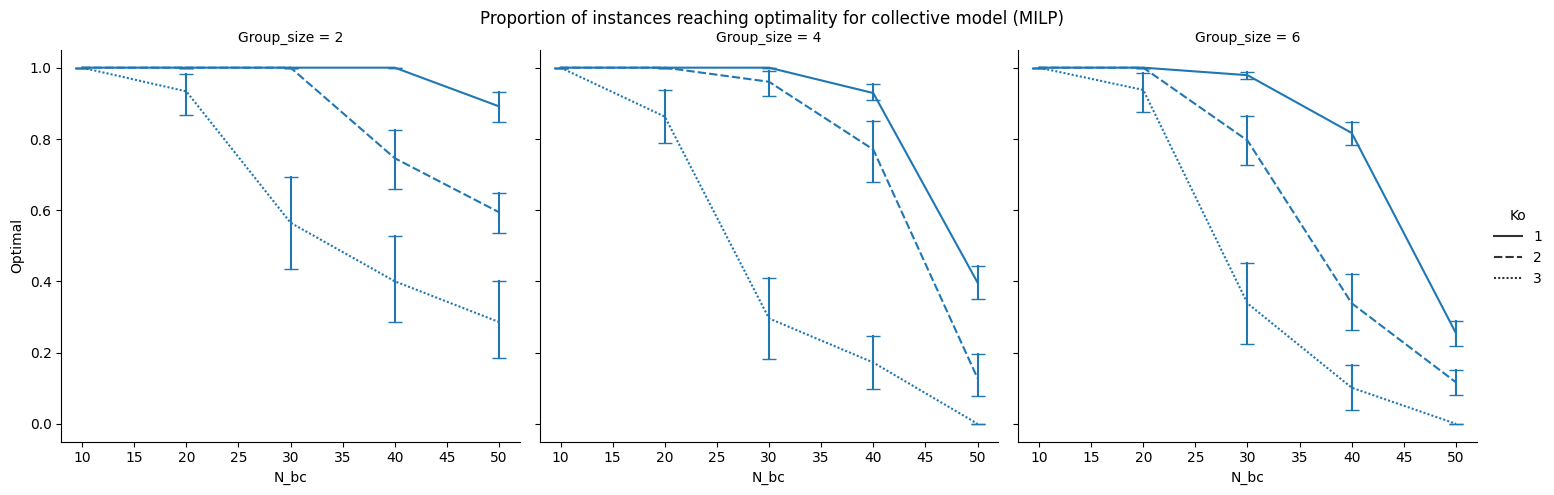

In [ ]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y=df_collective["Optimal"],
    col="Group_size",
    # row="Group_size",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Proportion of instances reaching optimality for collective model (MILP)")
g

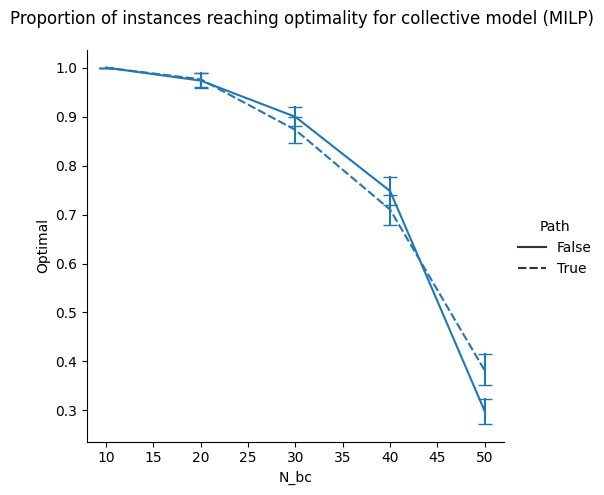

In [ ]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y=df_collective["Optimal"],
    # col="M",
    # row="Group_size",
    style="Path",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Proportion of instances reaching optimality for collective model (MILP)")
g

## Path optimal

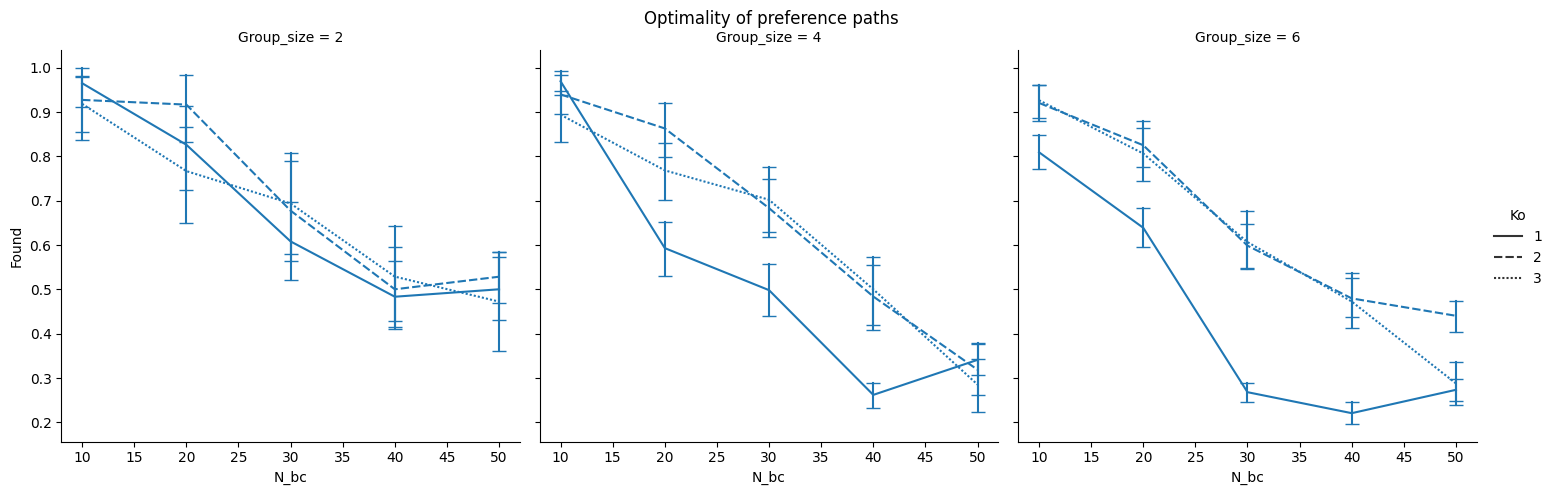

In [ ]:
g = sns.relplot(
    df_path,
    x="N_bc",
    y=df_path.loc[df_path["Length"] > 0, "Found"],
    # row="Group_size",
    col="Group_size",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Optimality of preference paths")
g

## Computing time

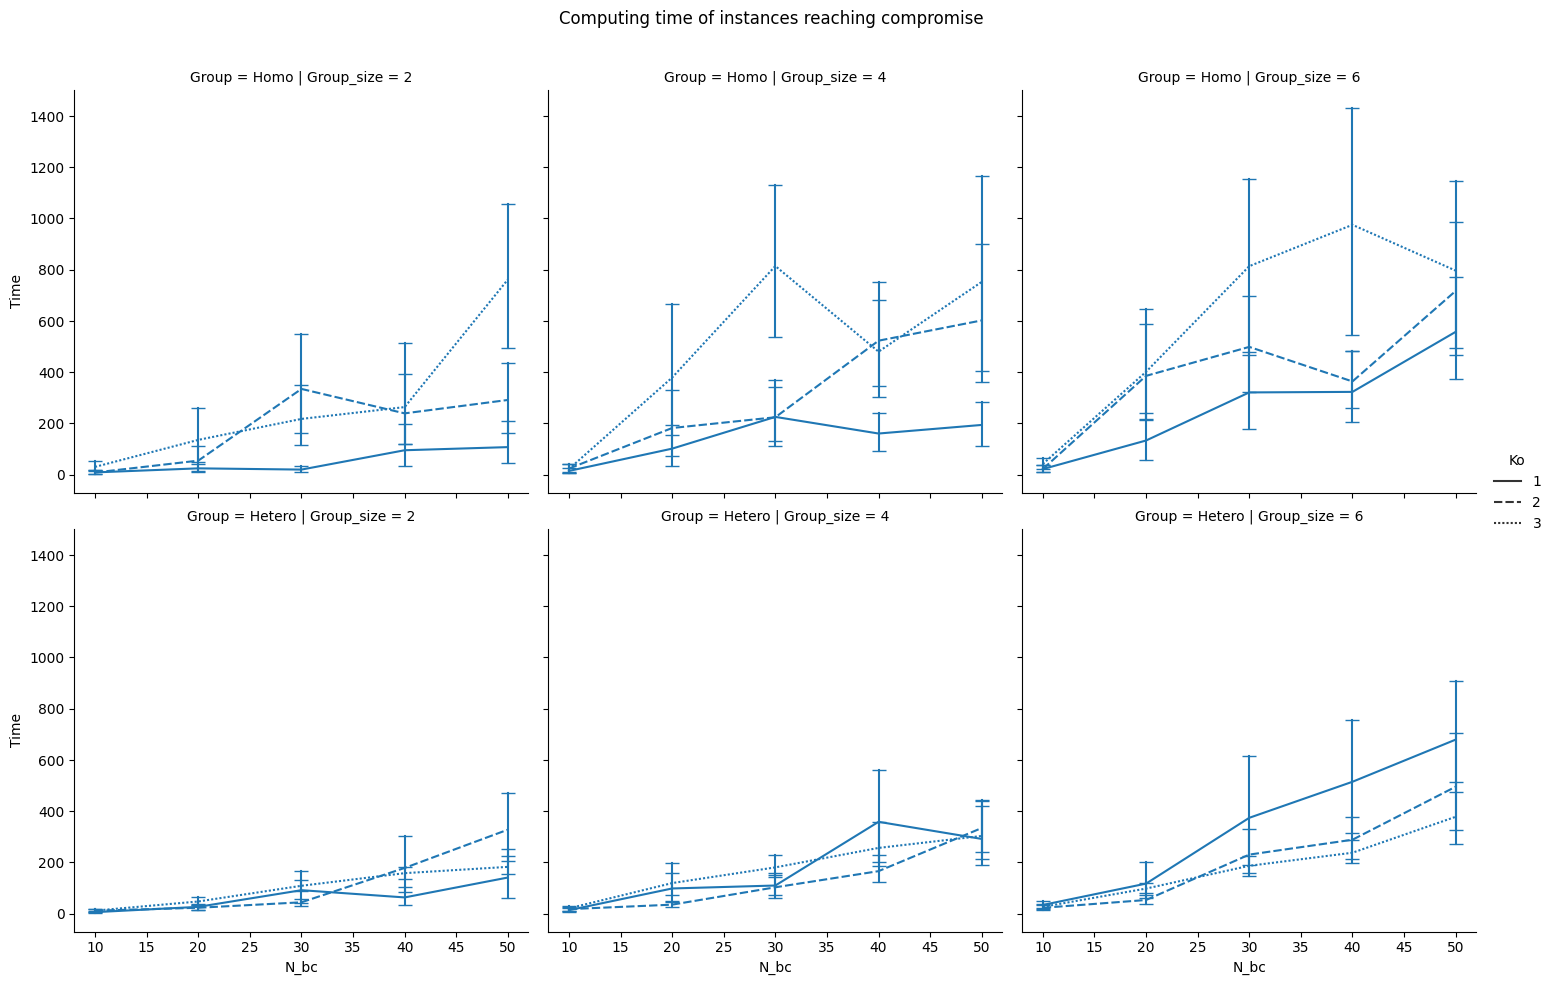

In [ ]:
g = sns.relplot(
    dff[dff["Compromise"]],
    x="N_bc",
    y="Time",
    row="Group",
    col="Group_size",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time of instances reaching compromise")
g

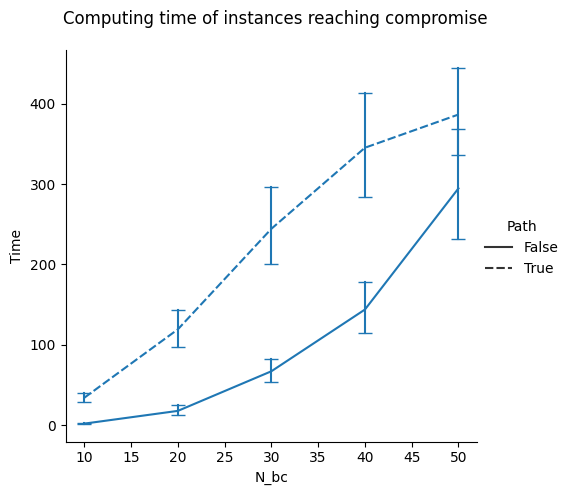

In [ ]:
g = sns.relplot(
    dff[dff["Compromise"]],
    x="N_bc",
    y="Time",
    # row="Group_size",
    # col="M",
    style="Path",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time of instances reaching compromise")
g

## Computing time per it

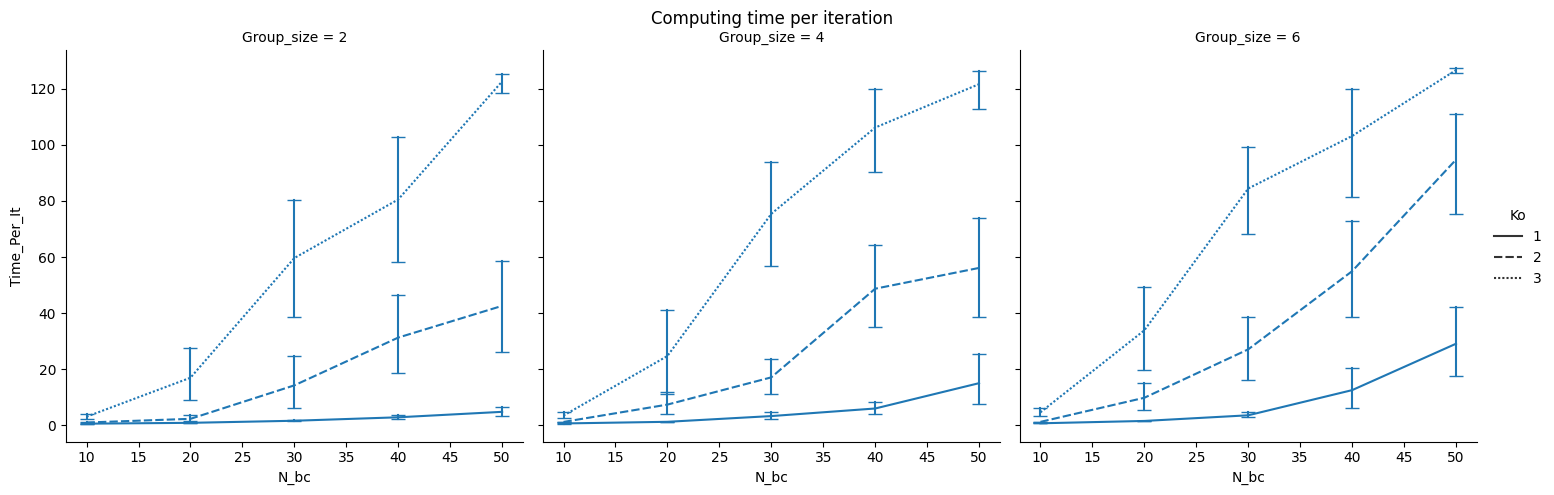

In [177]:
g = sns.relplot(
    dff[dff["Compromise"] & (~ dff["Path"]) & (dff["Group"] == "Homo")],
    x="N_bc",
    y="Time_Per_It",
    # row="Group",
    col="Group_size",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time per iteration")
g

tikzplotlib.save("mytikz.tex", standalone=True)

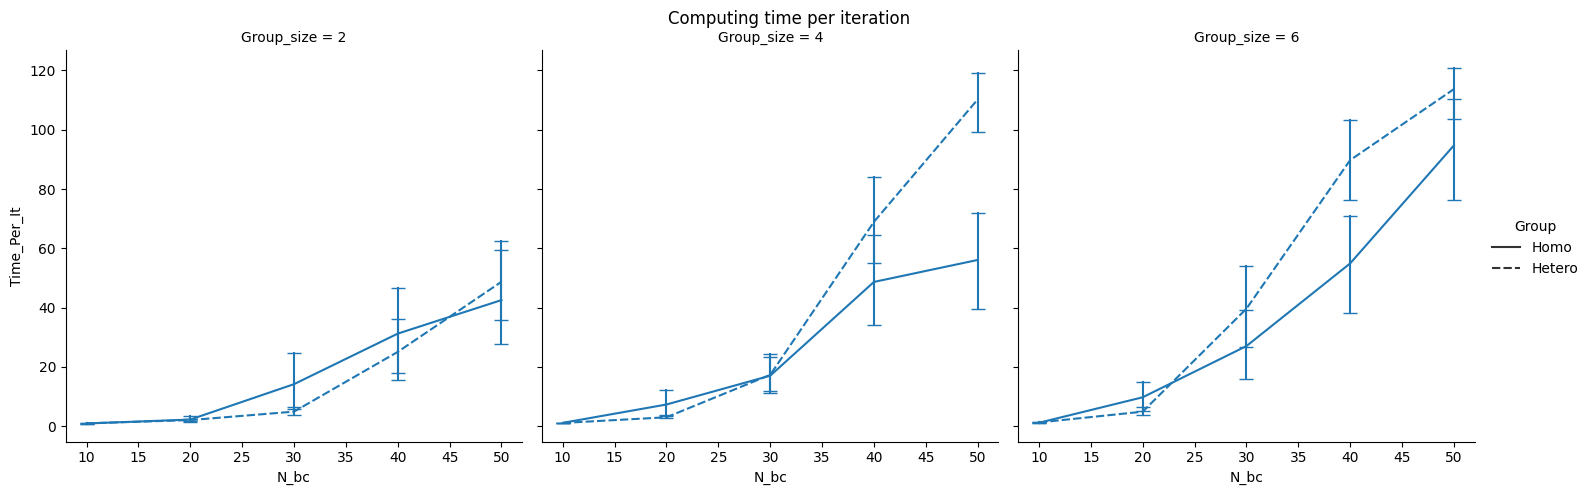

In [ ]:
g = sns.relplot(
    dff[dff["Compromise"] & (~ dff["Path"]) & (dff["Ko"] == 2)],
    x="N_bc",
    y="Time_Per_It",
    # row="Group",
    col="Group_size",
    style="Group",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time per iteration")
g

tikzplotlib.save("mytikz.tex", standalone=True)

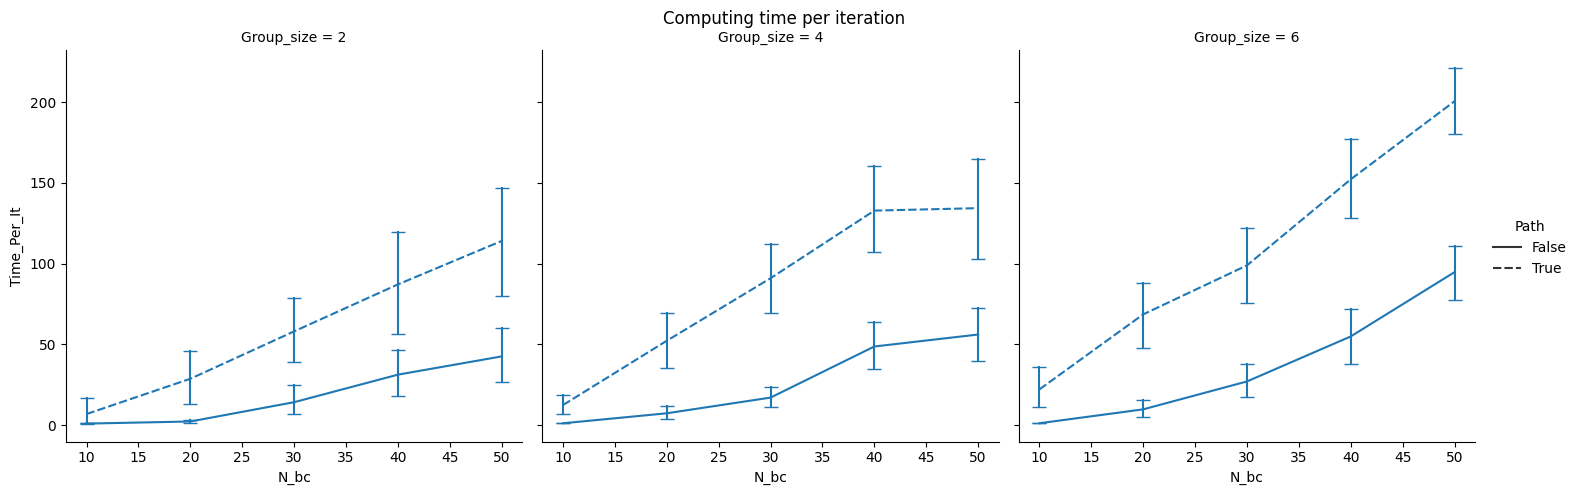

In [ ]:
g = sns.relplot(
    dff[dff["Compromise"] & (dff["Group"] == "Homo") & (dff["Ko"] == 2)],
    x="N_bc",
    y="Time_Per_It",
    # row="Group_size",
    col="Group_size",
    style="Path",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time per iteration")
g

tikzplotlib.save("mytikz.tex", standalone=True)

## MILP computing time

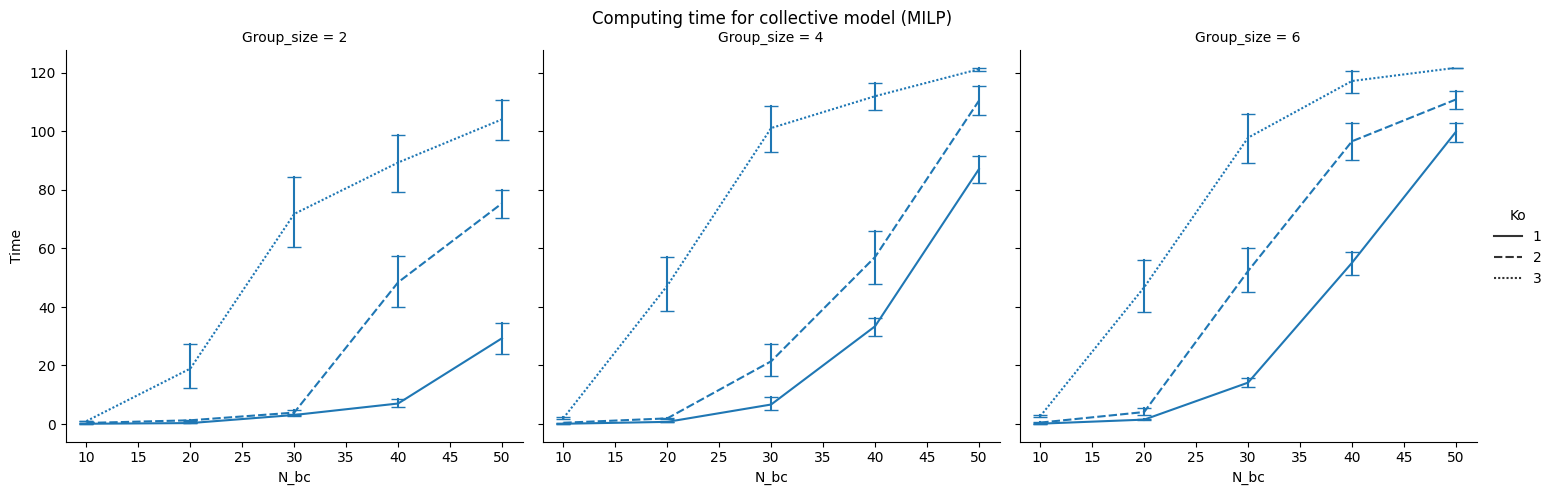

In [ ]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Time",
    # row="Group_size",
    col="Group_size",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time for collective model (MILP)")
g

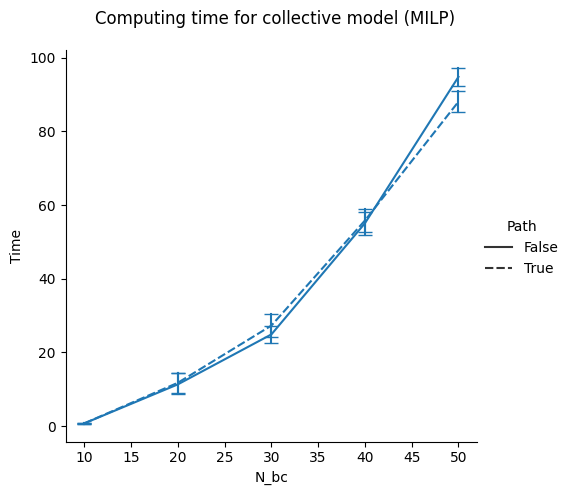

In [ ]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Time",
    # row="Group_size",
    # col="M",
    style="Path",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time for collective model (MILP)")
g

## Preference path computing time

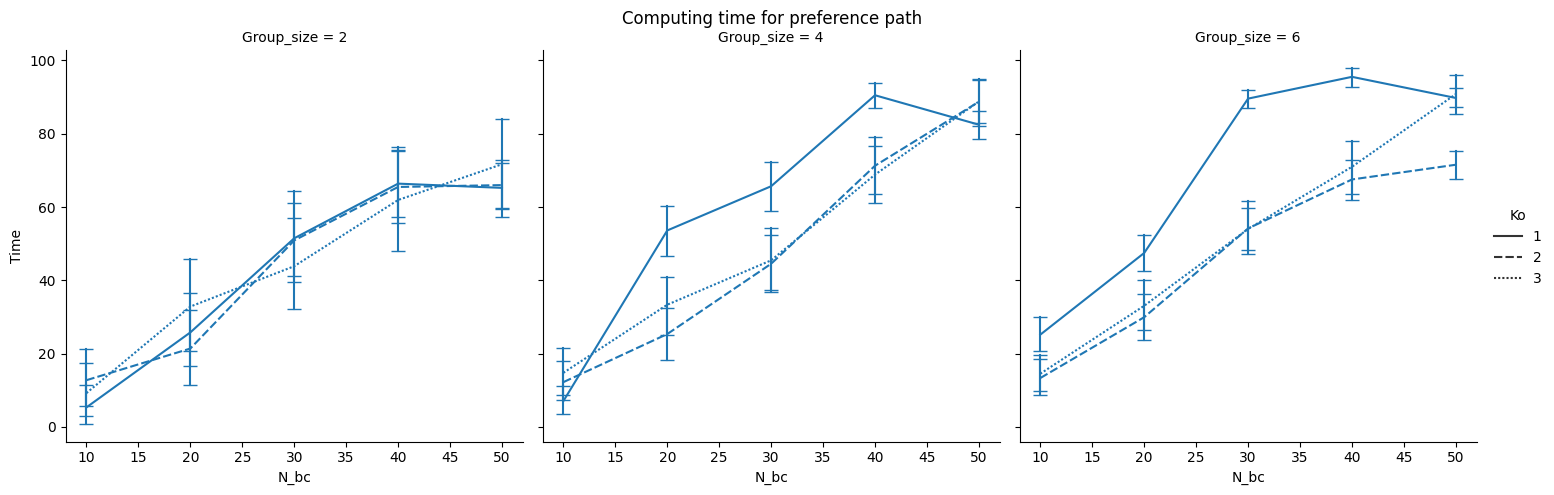

In [ ]:
g = sns.relplot(
    df_path,
    x="N_bc",
    y="Time",
    # row="Group_size",
    col="Group_size",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time for preference path")
g

## Iterations

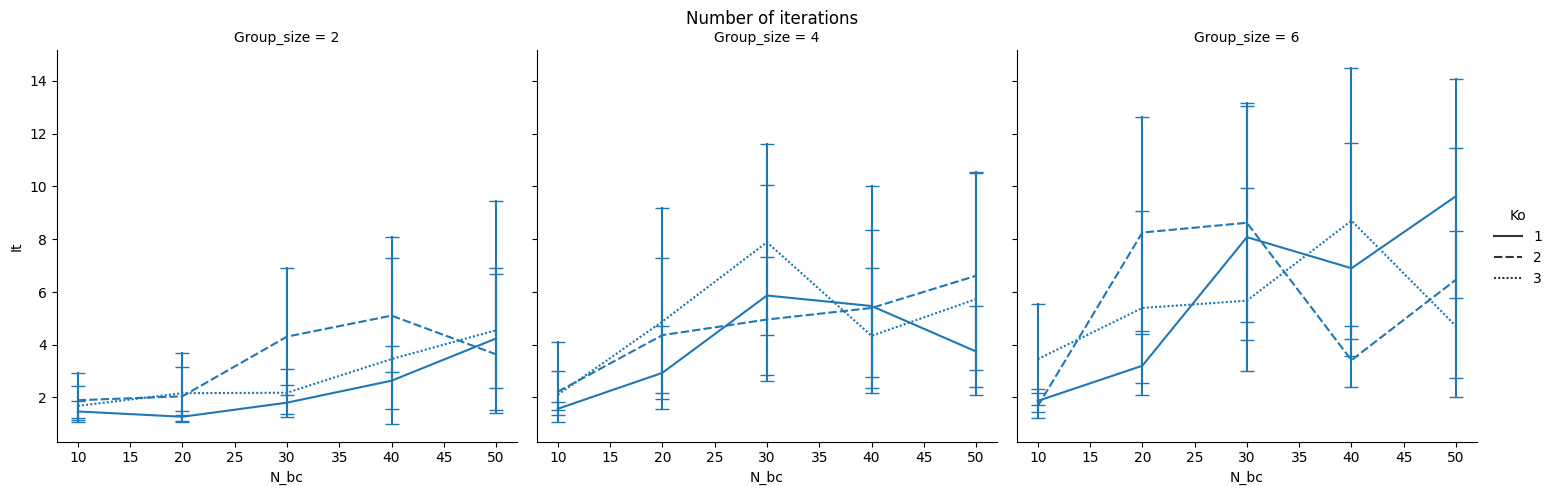

In [ ]:
g = sns.relplot(
    dff[dff["Compromise"] & (~dff["Path"]) & (dff["Group"] == "Homo")],
    x="N_bc",
    y="It",
    col="Group_size",
    # row="Group",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Number of iterations")
g

tikzplotlib.save("mytikz.tex", standalone=True)

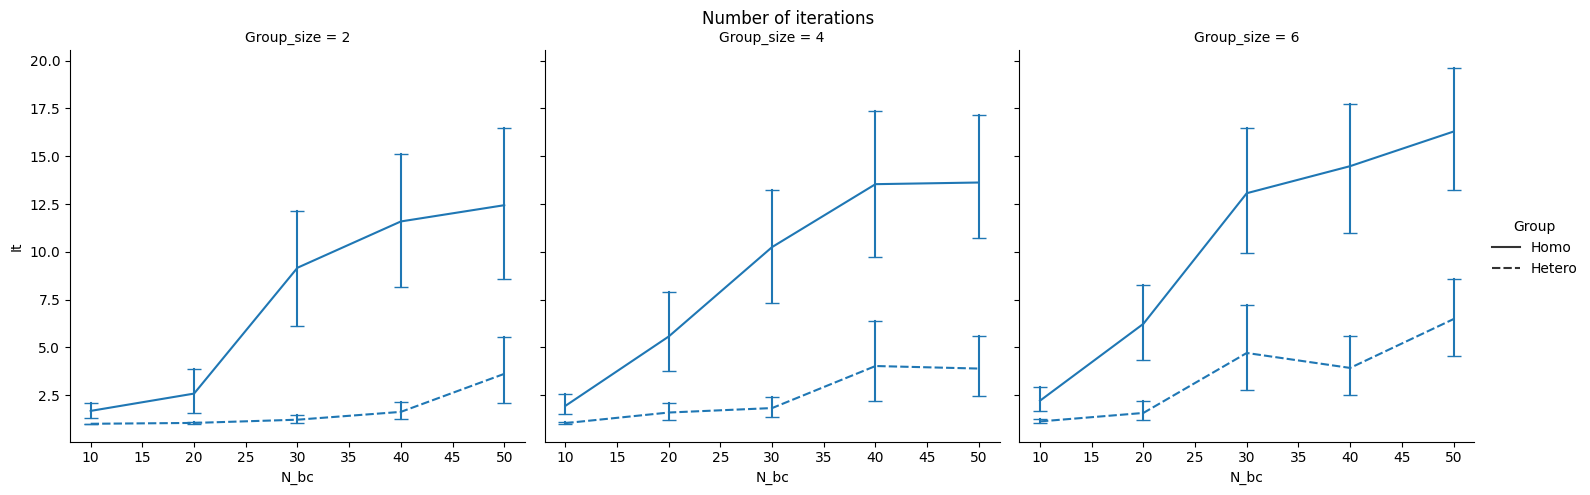

In [202]:
g = sns.relplot(
    dff[(~dff["Path"])],
    x="N_bc",
    y="It",
    col="Group_size",
    # row="Group",
    style="Group",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Number of iterations")
g

tikzplotlib.save("mytikz.tex", standalone=True)

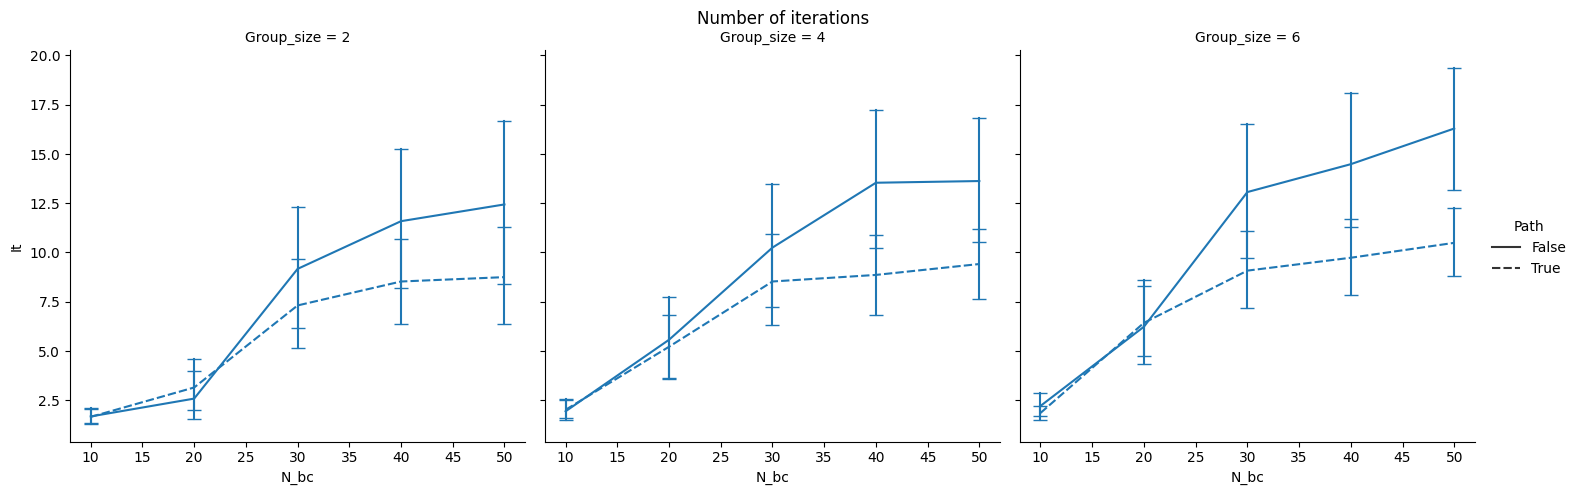

In [199]:
g = sns.relplot(
    dff[(dff["Group"] == "Homo")],
    x="N_bc",
    y="It",
    col="Group_size",
    # row="Group",
    style="Path",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Number of iterations")
g

tikzplotlib.save("mytikz.tex", standalone=True)

## Length of model preference paths

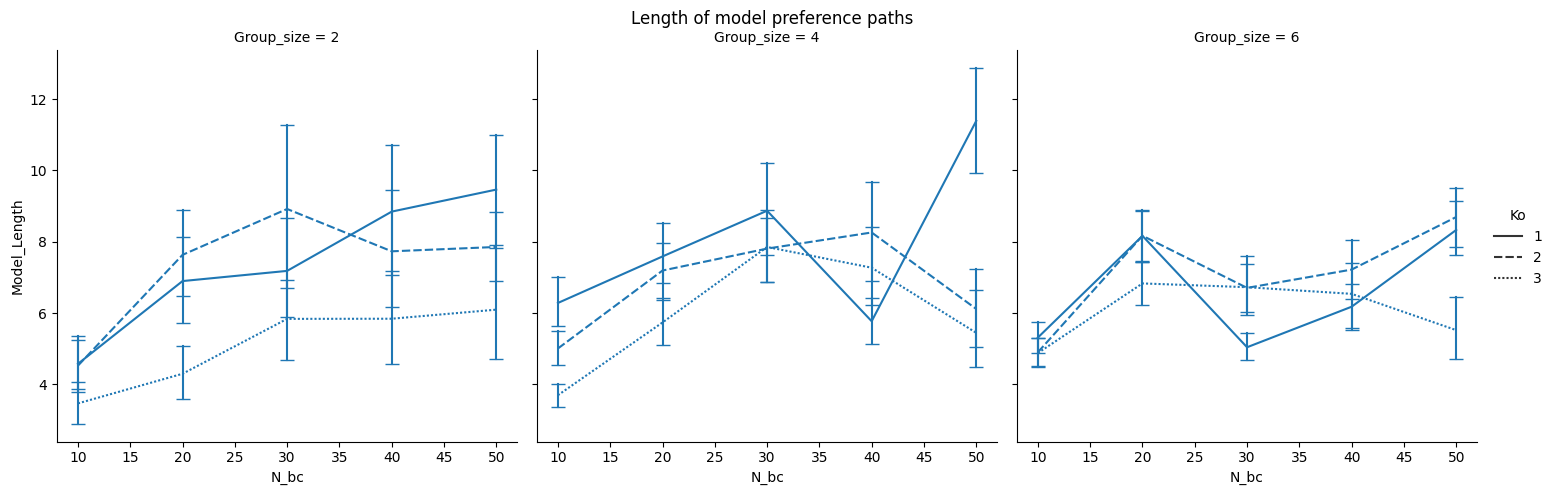

In [ ]:
g = sns.relplot(
    df_path,
    x="N_bc",
    y=df_path.loc[df_path["Length"] > 0, "Model_Length"],
    # row="Group_size",
    col="Group_size",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Length of model preference paths")
g

## Length of preference paths

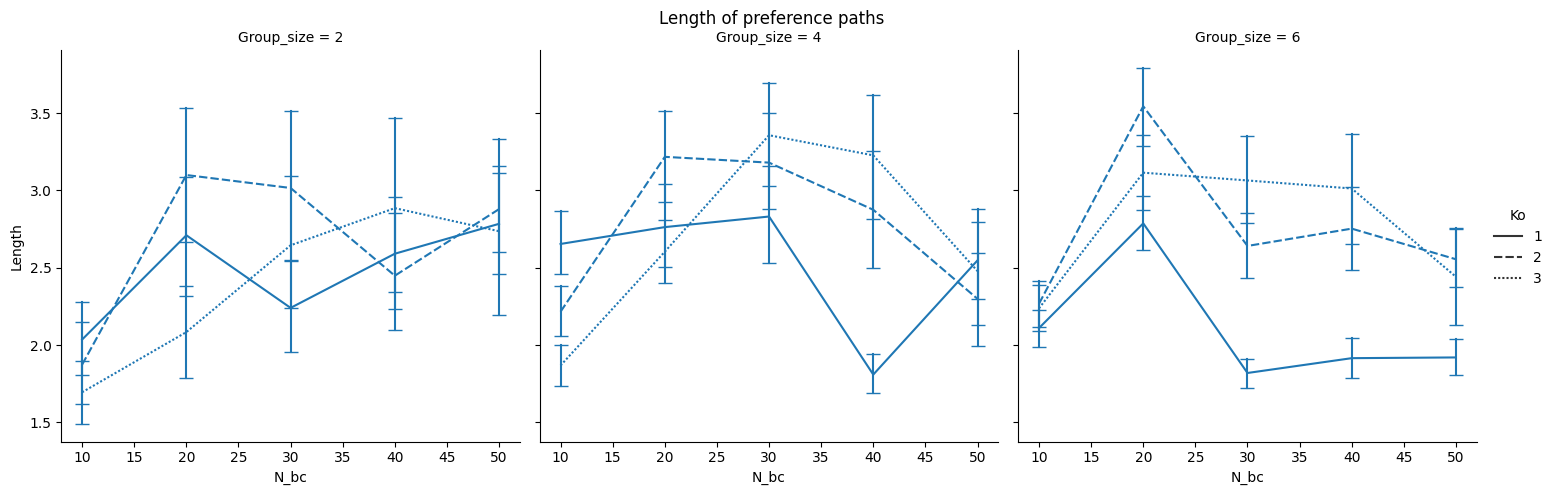

In [ ]:
g = sns.relplot(
    df_path,
    x="N_bc",
    y=df_path.loc[df_path["Length"] > 0, "Length"],
    # row="Group_size",
    col="Group_size",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Length of preference paths")
g